# Notebook de documentacion, tratamiento datos y entrenamiento


## Equipo
- Alumno 1 : Calabozo, Nicolas Daniel
- Alumno 2 : Lapolla, Martín Facundo

## Librerías

In [2]:
import os
import numpy as np
import cv2
import ssl
import time
import uuid
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_lfw_people
from sklearn.metrics import roc_curve, auc, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from facenet_pytorch import MTCNN, InceptionResnetV1
from tqdm import tqdm
from dotenv import load_dotenv
from typing import Any, Literal, Optional
from pydantic import BaseModel, ConfigDict, Field

from sklearn.metrics import pairwise_distances
import psycopg
from pgvector.psycopg import register_vector 


ssl._create_default_https_context = ssl._create_unverified_context

import sys
sys.path.append(os.path.abspath('./src'))
from lib.storage.pgvector_store import PgVectorEmbeddingStore
from lib.schemas import EmbeddingRecord

load_dotenv(dotenv_path="./src/.env")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

Usando dispositivo: cpu


In [3]:
#Setup de BBDD vectorial 
store = PgVectorEmbeddingStore(
    dbname=os.getenv("POSTGRES_DB"),
    user=os.getenv("POSTGRES_USER"),
    password=os.getenv("POSTGRES_PASSWORD"),
    host=os.getenv("POSTGRES_HOST"),
    port=os.getenv("POSTGRES_PORT"),
    embedding_dim=os.getenv("EMBEDDING_DIM")
)

In [4]:
#Setup de MCNN IMG(160x160px)
mtcnn = MTCNN(image_size=160, margin=20, device=device, post_process=True)

### EDA

In [ ]:
lfw_data = fetch_lfw_people(
    min_faces_per_person=20,
    color=True,
     resize=1.0,
     slice_=None,
     download_if_missing=True)
print("Descarga completa - Imágenes sin recortar, tamaño 250x250")

X = lfw_data.images
y = lfw_data.target
num_classes = len(lfw_data.target_names)

# Dividimos en Train y Validation (80% / 20%)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

class SklearnLFWDataset(Dataset):
    def __init__(self, images, labels, mtcnn):
        self.images = images
        self.labels = labels
        self.mtcnn = mtcnn

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_np = (self.images[idx] * 255).astype(np.uint8)
        face = self.mtcnn(img_np)
        if face is None:
            face = torch.zeros(3, 160, 160)
            
        return face, self.labels[idx]

#Dataset de Train
train_loader = DataLoader(SklearnLFWDataset(X_train, y_train, mtcnn), batch_size=32, shuffle=True)
print("Loader de Train instanciado")
#Dataset de Validación
val_loader = DataLoader(SklearnLFWDataset(X_val, y_val, mtcnn), batch_size=32, shuffle=False)
print("Loader de Validación instanciado")

### Entrenamiento

#### Clases

In [6]:
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

#### Funciones

In [7]:
#Función para obtener el modelo preparado para finetuning
def get_model(num_classes):
    model = InceptionResnetV1(pretrained='vggface2', classify=True).to(device)
    #Congelamos el backbone
    for param in model.parameters():
        param.requires_grad = False
    #Generamos el nuevo head con el número de clases de LFW
    model.logits = nn.Linear(512, num_classes).to(device)
    for param in model.logits.parameters():
        param.requires_grad = True
        
    return model

In [8]:
def train_con_early_stopping(model, train_loader, val_loader, max_epochs=20):
    """
    Parametros:
    model: El modelo al que vamos a entrenar
    train_loader: El dataset de train
    val_loader: El dataset de validación
    max_epochs: Cantidad de épocas máximas para entrenar el modelo
    """
    criterion = nn.CrossEntropyLoss() 
    #Optimizador adam con learning rate bajo
    optimizer = optim.Adam(model.logits.parameters(), lr=0.001)
    #Early stopping con paciencia 3, mínima diferencia de 0.01
    #Si al realizar una época, la métrica no mejora en 0.01
    #se disminuye en uno la paciencia
    early_stopping = EarlyStopping(patience=3, min_delta=0.01)
    
    train_losses = []
    val_losses = []
    
    for epoch in range(max_epochs):
        # Entrenamiento
        model.train()
        running_loss = 0.0
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{max_epochs} [Train]"):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            
        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        # Validación
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                
        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        
        print(f"Epoch [{epoch+1}/{max_epochs}] | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        
        early_stopping(avg_val_loss)
        if early_stopping.early_stop:
            print("Early stopping disparado. Deteniendo entrenamiento.")
            break
            
    return model, train_losses, val_losses

Epoch 1/20 [Train]: 100%|██████████| 76/76 [01:58<00:00,  1.55s/it]


Epoch [1/20] | Train Loss: 1.1636 | Val Loss: 0.2591


Epoch 2/20 [Train]: 100%|██████████| 76/76 [01:57<00:00,  1.54s/it]


Epoch [2/20] | Train Loss: 0.1561 | Val Loss: 0.2201


Epoch 3/20 [Train]: 100%|██████████| 76/76 [02:00<00:00,  1.58s/it]


Epoch [3/20] | Train Loss: 0.1150 | Val Loss: 0.2136
EarlyStopping counter: 1 out of 3


Epoch 4/20 [Train]: 100%|██████████| 76/76 [01:57<00:00,  1.55s/it]


Epoch [4/20] | Train Loss: 0.0934 | Val Loss: 0.2165
EarlyStopping counter: 2 out of 3


Epoch 5/20 [Train]: 100%|██████████| 76/76 [01:56<00:00,  1.53s/it]


Epoch [5/20] | Train Loss: 0.0772 | Val Loss: 0.2226
EarlyStopping counter: 3 out of 3
Early stopping disparado. Deteniendo entrenamiento.


In [9]:
model_dir = os.getenv("MODEL_PATH", "models")
model_name = os.getenv("MODEL_NAME", "inception_resnet_lfw_finetuned.pth")
save_path = os.path.join(model_dir, model_name)
model = get_model(len(lfw_data.target_names))
if os.path.exists(save_path):
    print(f"El modelo ya existe en {save_path}. Cargando pesos guardados.")
    model.load_state_dict(torch.load(save_path, map_location=device))
else:
    print("Iniciando el entrenamiento del modelo")
    model, train_losses, val_losses = train_con_early_stopping(model, train_loader, val_loader, max_epochs=20)
    os.makedirs(model_dir, exist_ok=True)
    torch.save(model.state_dict(), save_path)
    print(f"Modelo guardado exitosamente en: {save_path}")

El modelo ya existe en models\face_detection.pth. Cargando pesos guardados.


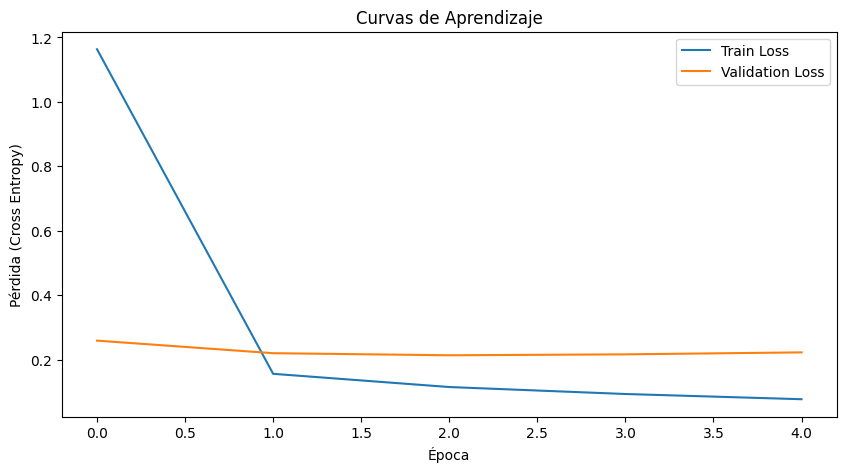

In [10]:
# Graficar curvas de pérdida
plt.figure(figsize=(10,5))
plt.title("Modelo InceptionResnetV1 Fine-Tuned")
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Curvas de Aprendizaje')
plt.xlabel('Época')
plt.ylabel('Pérdida (Cross Entropy)')
plt.legend()
plt.show()

In [ ]:
from sklearn import model_selection
def extract_embeddings(modelo, loader):

    modelo.eval()
    embeddings = []
    etiquetas = []
    
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Extrayendo embeddings"):
            inputs = inputs.to(device)
            out = modelo(inputs) 
            embeddings.append(out.cpu().numpy())
            etiquetas.append(labels.numpy())
            
    return np.vstack(embeddings), np.concatenate(etiquetas)

def extract_embeddings(modelo, loader):
    """
    Función para la extracción de embeddings.
    Retorna:
    - tuple(Embeddings, Etiquetas)
    """
    modelo.eval()

    #Guardamos el estado de la propiedad classify
    estado_original_classify = getattr(modelo, 'classify', False)

    # Apagamos la clasificación para que el método forward
    # ignore el head y nos devuelva los embeddings normalizados
    modelo.classify = False

    embeddings = []
    etiquetas = []

    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Extrayendo embeddings"):
            inputs = inputs.to(device)
            out = modelo(inputs) 
            embeddings.append(out.cpu().numpy())
            etiquetas.append(labels.numpy())
            
    # 3. Restauramos el estado original por si luego quieres predecir clases con él
    modelo.classify = estado_original_classify
        
    return np.vstack(embeddings), np.concatenate(etiquetas)

#Extraemos vectores del modelo sin entrenar
modelo_base = InceptionResnetV1(pretrained='vggface2', classify=False).to(device)
print("Evaluando modelo base")
emb_train_base, y_train_base = extract_embeddings(modelo_base, train_loader)
emb_val_base, y_val_base = extract_embeddings(modelo_base, val_loader)

knn_base = KNeighborsClassifier(n_neighbors=3, metric='cosine')
knn_base.fit(emb_train_base, y_train_base)
acc_base = accuracy_score(y_val_base, knn_base.predict(emb_val_base))
print(f"🏆 Accuracy Modelo BASE: {acc_base*100:.2f}%")


try:
    print("\nEvaluando modelo FINE-TUNED...")
    emb_train_ft, y_train_ft = extract_embeddings(model, train_loader)
    emb_val_ft, y_val_ft = extract_embeddings(model, val_loader)

    knn_ft = KNeighborsClassifier(n_neighbors=3, metric='cosine')
    knn_ft.fit(emb_train_ft, y_train_ft)
    acc_ft = accuracy_score(y_val_ft, knn_ft.predict(emb_val_ft))
    print(f"🏆 Accuracy Modelo FINE-TUNED: {acc_ft*100:.2f}%")
except Exception as e:
    print(f"No se pudo cargar el modelo fine-tuned: {e}")

Evaluando modelo base


Extrayendo embeddings:  30%|███       | 23/76 [00:34<01:19,  1.50s/it]


KeyboardInterrupt: 

In [ ]:
def generate_and_store_embeddings(lfw_data, mtcnn, store: PgVectorEmbeddingStore):
    print("Generando embeddings y guardando en PGVector")
    
    # Cargamos el backbone SIN la capa de clasificación (classify=False) para sacar embeddings
    embedding_model = InceptionResnetV1(pretrained='vggface2', classify=False).to(device)
    embedding_model.eval()

    loop = tqdm(range(len(lfw_data.images)))
    for idx in loop:
        img_np = (lfw_data.images[idx] * 255).astype(np.uint8)
        label_id = lfw_data.target[idx]
        person_name = lfw_data.target_names[label_id]
        
        # Detectar
        face = mtcnn(img_np)
        if face is None:
            continue
            
        # Generar embedding
        face = face.unsqueeze(0).to(device)
        with torch.no_grad():
            embedding = embedding_model(face).cpu().numpy().flatten()
            
        # Guardar en BD usando el esquema de EmbeddingRecord
        record = EmbeddingRecord(
            #Usamos un uuid4 como primary key ya que genera cadenas aleatorias únicas
            id_imagen=str(uuid.uuid4()),
            embedding=embedding.tolist(),
            #El path lo definimos nosotros mediante {nombre}_{índice de foto}
            path=f"{person_name}_{idx}.jpg",
            etiqueta=person_name,
            metadata={"source": "LFW Sklearn"}
        )
        store.append(record)

In [13]:
generate_and_store_embeddings(lfw_data, mtcnn, store)

Generando embeddings y guardando en PGVector...


100%|██████████| 3023/3023 [05:56<00:00,  8.49it/s]


Calculando Curva ROC para el modelo BASE...


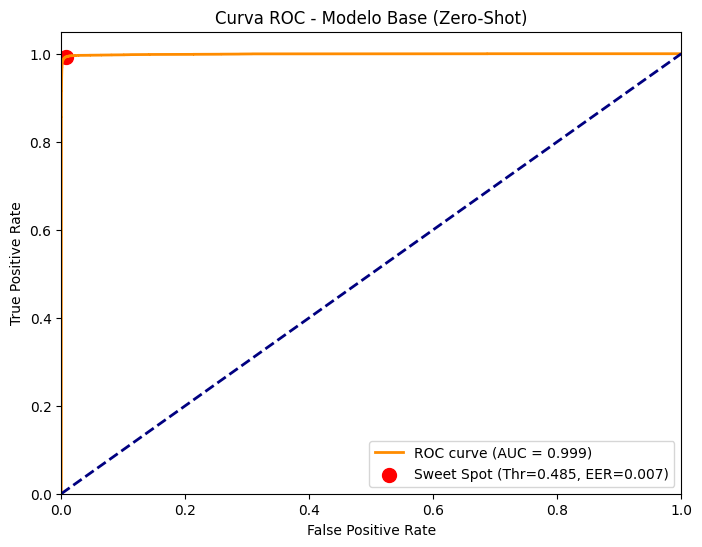

In [14]:
def plot_roc_curve(embeddings, labels, title="Curva ROC"):
    # Calculamos la matriz de similitud coseno completa
    dist_matrix = pairwise_distances(embeddings, metric='cosine')
    sim_matrix = 1 - dist_matrix # Similitud coseno (1 a -1)
    
    y_true = []
    y_scores = []
    
    n = len(labels)
    # Extraemos pares (solo la mitad superior de la matriz para no duplicar)
    for i in range(n):
        for j in range(i+1, n):
            is_same = int(labels[i] == labels[j])
            y_true.append(is_same)
            y_scores.append(sim_matrix[i, j])
            
    # Calculamos FPR, TPR y AUC
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    
    # Encontrar el Sweet Spot (Umbral óptimo, EER - Equal Error Rate)
    # Buscamos el punto donde False Positive Rate y False Negative Rate (1-TPR) se cruzan
    fnr = 1 - tpr
    eer_threshold_idx = np.nanargmin(np.absolute((fnr - fpr)))
    opt_threshold = thresholds[eer_threshold_idx]
    eer = fpr[eer_threshold_idx]
    
    plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.scatter(fpr[eer_threshold_idx], tpr[eer_threshold_idx], color='red', s=100, label=f'Sweet Spot (Thr={opt_threshold:.3f}, EER={eer:.3f})')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc="lower right")
    plt.show()

# Graficar para el modelo Base
print("Calculando Curva ROC para el modelo BASE...")
plot_roc_curve(emb_val_base, y_val_base, title="Curva ROC - Modelo Base (Zero-Shot)")

# Graficar para el modelo Fine-Tuned
if 'emb_val_ft' in locals():
    print("Calculando Curva ROC para el modelo FINE-TUNED...")
    plot_roc_curve(emb_val_ft, y_val_ft, title="Curva ROC - Modelo Fine-Tuned")
